Why Asymmetry Might Exist
Clinical Reasons
1. Asymmetric error costs

FP (τ-0.1 misclassified): Unnecessary treatment, anxiety, financial cost
FN (τ+0.1 misclassified): Missed intervention, disease progression, death
If FN >> FP in cost, then τ+δ patients are higher risk

2. Base rate effects

Below τ: majority class (11% prior → 89% are negative)

More training samples → more stable estimates
Lower uncertainty per unit distance


Above τ: minority class (11% are positive)

Fewer training samples → noisier estimates
Higher uncertainty per unit distance



3. Feature heterogeneity

Negative class: might be homogeneous ("healthy looks healthy")
Positive class: might be heterogeneous (disease has multiple phenotypes)
More variance in positive class → higher uncertainty even at same distance from τ

Statistical Reasons
4. Calibration quality

Models often calibrate differently for majority vs minority class
Platt scaling might work better on one side

5. Ensemble behavior

Variance structure might differ by predicted class

In [2]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'ms_neuro'
analysis_name = 'ms_progression'
outcome_name = 'progression_independent_from_relapses'
build_ensemble_csv(analysis_name, outcome_name)


all_patients = pd.read_csv(f'../data/{dataset}/X.csv')
all_patients_y = pd.read_csv(f'../data/{dataset}/y.csv')

all_patients['label'] = all_patients_y[outcome_name].astype(int)


# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats['idx'].values)



uncertainty_results = compute_uncertainties(probs_raw_df, tau=0.11)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_copy = patients_stats.copy()

# 2. Add the results to your main stats table
patients_stats_copy['H_Total'] = uncertainty_results['H_Total']
patients_stats_copy['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_copy['I_Epistemic'] = uncertainty_results['I_Epistemic']
patients_stats_copy['Distance_to_Tau'] = uncertainty_results['Distance_to_Tau']
patients_stats_copy['MW_H_Total'] = uncertainty_results['MW_H_Total']
patients_stats_copy['MW_Std'] = uncertainty_results['MW_Std']
patients_stats_copy['H_Tau'] = uncertainty_results['H_Tau']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients['label'].sum() / len(all_patients)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)


Skipping stacking as it's not in the list of models to include.
Skipping voting as it's not in the list of models to include.
Successfully aggregated 21600 predictions across 719 unique patients.
Baseline entropy: 0.5120043783280033


In [9]:
patients_stats_copy

,idx,mu,sigma,label,n_predictions,all_probs,H_Total,C_Aleatoric,I_Epistemic,Distance_to_Tau,MW_H_Total,MW_Std,H_Tau
idx,,,,,,,,,,,,,
0,0,0.266000,0.111095,0,30,"[0.17, 0.16, 0.15, 0.16, 0.14, 0.16, 0.42, 0.4...",0.835666,0.790581,0.045085,0.156000,5.034133,0.657998,0.977723
1,1,0.322800,0.112529,1,25,"[0.19, 0.19, 0.19, 0.19, 0.2, 0.44, 0.33, 0.36...",0.907400,0.866789,0.040612,0.212800,4.072713,0.494861,0.958359
2,2,0.116000,0.023930,0,20,"[0.15, 0.13, 0.14, 0.14, 0.12, 0.07, 0.13, 0.1...",0.517753,0.513728,0.004025,0.006000,32.359539,1.457738,0.999967
3,3,0.252286,0.083528,1,35,"[0.2, 0.19, 0.17, 0.2, 0.17, 0.21, 0.23, 0.3, ...",0.814881,0.789186,0.025695,0.142286,5.351000,0.540605,0.981484
4,4,0.234000,0.113712,0,20,"[0.07, 0.08, 0.07, 0.09, 0.37, 0.39, 0.38, 0.2...",0.784919,0.730289,0.054630,0.124000,5.857607,0.827113,0.985952
...,...,...,...,...,...,...,...,...,...,...,...,...,...
714,714,0.114400,0.025344,0,25,"[0.11, 0.11, 0.12, 0.1, 0.11, 0.12, 0.15, 0.14...",0.513047,0.508261,0.004786,0.004400,35.628241,1.724461,0.999982
715,715,0.075429,0.019903,0,35,"[0.09, 0.09, 0.09, 0.1, 0.09, 0.09, 0.1, 0.05,...",0.385863,0.381783,0.004080,0.034571,8.657182,0.440119,0.927527
716,716,0.197250,0.111723,1,40,"[0.08, 0.07, 0.07, 0.08, 0.07, 0.09, 0.08, 0.0...",0.716394,0.660749,0.055645,0.087250,7.366518,1.134370,0.993056


In [8]:
# For each distance δ from boundary
deltas = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
mean_probs = patients_stats_copy['mu']
tau = 0.11

for delta in deltas:
    # Patients on left side (below threshold)
    left_mask = (mean_probs >= tau - delta) & (mean_probs < tau)
    left_variance = probs_raw_df[left_mask].var(axis=1).mean()
    # Patients on right side (above threshold)  
    right_mask = (mean_probs >= tau) & (mean_probs < tau + delta)
    right_variance = probs_raw_df[right_mask].var(axis=1).mean()
    
    print(f"δ={delta}: Left var={left_variance:.4f}, Right var={right_variance:.4f}")
    print(f"  Ratio: {right_variance / left_variance:.2f}")

δ=0.01: Left var=0.0006, Right var=0.0008
  Ratio: 1.31
δ=0.02: Left var=0.0006, Right var=0.0012
  Ratio: 1.89
δ=0.05: Left var=0.0006, Right var=0.0016
  Ratio: 2.80
δ=0.1: Left var=0.0006, Right var=0.0031
  Ratio: 5.57
δ=0.15: Left var=0.0006, Right var=0.0044
  Ratio: 7.83
δ=0.2: Left var=0.0006, Right var=0.0046
  Ratio: 8.24


In [11]:
predictions = (mean_probs >= tau).astype(int)
outcomes = patients_stats_copy['label'].values
for delta in deltas:
    # Left side (predicted negative, near boundary)
    left_mask = (mean_probs >= tau - delta) & (mean_probs < tau)
    left_errors = (predictions[left_mask] != outcomes[left_mask]).mean()
    
    # Right side (predicted positive, near boundary)
    right_mask = (mean_probs >= tau) & (mean_probs < tau + delta)
    right_errors = (predictions[right_mask] != outcomes[right_mask]).mean()
    
    print(f"δ={delta}: Left error={left_errors:.3f}, Right error={right_errors:.3f}")
    print(f"  Ratio: {right_errors / left_errors:.2f}")

δ=0.01: Left error=0.111, Right error=0.826
  Ratio: 7.43
δ=0.02: Left error=0.099, Right error=0.827
  Ratio: 8.35
δ=0.05: Left error=0.048, Right error=0.838
  Ratio: 17.45
δ=0.1: Left error=0.047, Right error=0.807
  Ratio: 17.16
δ=0.15: Left error=0.047, Right error=0.774
  Ratio: 16.46
δ=0.2: Left error=0.047, Right error=0.769
  Ratio: 16.36


In [12]:
# Among patients who actually progressed, how variable are their predictions?
for delta in deltas:
    # True positives near boundary
    left_tp = (mean_probs >= tau - delta) & (mean_probs < tau) & (outcomes == 1)
    left_outcome_var = mean_probs[left_tp].std()
    
    right_tp = (mean_probs >= tau) & (mean_probs < tau + delta) & (outcomes == 1)
    right_outcome_var = mean_probs[right_tp].std()
    
    print(f"δ={delta}: Left TP spread={left_outcome_var:.4f}, Right TP spread={right_outcome_var:.4f}")

δ=0.01: Left TP spread=0.0043, Right TP spread=0.0037
δ=0.02: Left TP spread=0.0069, Right TP spread=0.0036
δ=0.05: Left TP spread=0.0141, Right TP spread=0.0149
δ=0.1: Left TP spread=0.0141, Right TP spread=0.0283
δ=0.15: Left TP spread=0.0141, Right TP spread=0.0435
δ=0.2: Left TP spread=0.0141, Right TP spread=0.0497


In [13]:
features = all_patients.drop(columns=['label'])

# Compare feature variance by side
for delta in deltas:
    left_mask = (mean_probs >= tau - delta) & (mean_probs < tau)
    right_mask = (mean_probs >= tau) & (mean_probs < tau + delta)
    
    left_feature_variance = features[left_mask].var(axis=0).mean()
    right_feature_variance = features[right_mask].var(axis=0).mean()
    
    print(f"δ={delta}: Left feature var={left_feature_variance:.4f}")
    print(f"          Right feature var={right_feature_variance:.4f}")

δ=0.01: Left feature var=61.9912
          Right feature var=46.6635
δ=0.02: Left feature var=46.3822
          Right feature var=37.6028
δ=0.05: Left feature var=23.5671
          Right feature var=47.0111
δ=0.1: Left feature var=23.1827
          Right feature var=57.1782
δ=0.15: Left feature var=23.1827
          Right feature var=54.9608
δ=0.2: Left feature var=23.1827
          Right feature var=54.9530


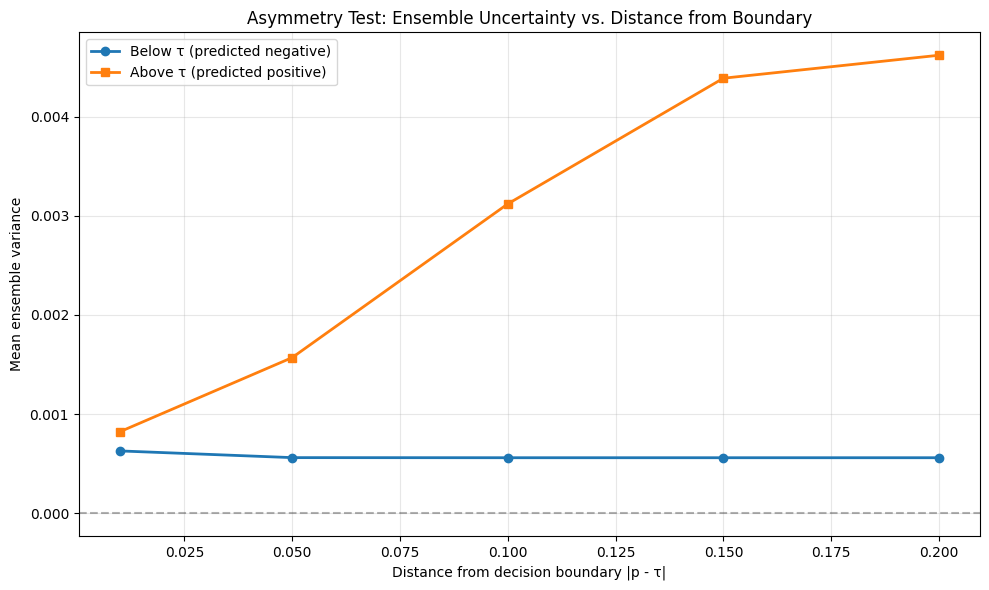

In [15]:
import matplotlib.pyplot as plt

# Create symmetric bins around tau
bins_left = tau - np.array([0.20, 0.15, 0.10, 0.05, 0.01])
bins_right = tau + np.array([0.01, 0.05, 0.10, 0.15, 0.20])

# Compute metric for each bin
left_metrics = []
right_metrics = []

for i, (bl, br) in enumerate(zip(bins_left[::-1], bins_right)):
    # Left bin
    left_mask = (mean_probs >= bl) & (mean_probs < tau)
    left_metrics.append(probs_raw_df[left_mask].var(axis=1).mean())
    
    # Right bin  
    right_mask = (mean_probs >= tau) & (mean_probs < br)
    right_metrics.append(probs_raw_df[right_mask].var(axis=1).mean())

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
distances = [0.01, 0.05, 0.10, 0.15, 0.20]

ax.plot(distances, left_metrics, 'o-', label='Below τ (predicted negative)', linewidth=2)
ax.plot(distances, right_metrics, 's-', label='Above τ (predicted positive)', linewidth=2)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Distance from decision boundary |p - τ|')
ax.set_ylabel('Mean ensemble variance')
ax.set_title('Asymmetry Test: Ensemble Uncertainty vs. Distance from Boundary')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()